# Phase 1: 所得流出（交易損失）の定量化

コストプッシュインフレ（輸入価格ショック）による日本の所得流出を5グループ別に推計する。

**推計式**: ΔTL_g(t) = M_g(2020) × (P_g(t) / 100 − 1)

- M_g(2020): IO表 2020年 グループgの輸入額（十億円）
- P_g(t): 日銀CGPI輸入物価指数（2020=100）

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import japanize_matplotlib

from src.analysis.trade_loss import (
    compute_trade_loss,
    compute_total_trade_loss,
    compute_annual_price_index,
)
from src.analysis.import_content import compute_group_import_content

## 1-1. 輸入物価指数の推移（2020=100）

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/trade-loss/annual_price_index.csv


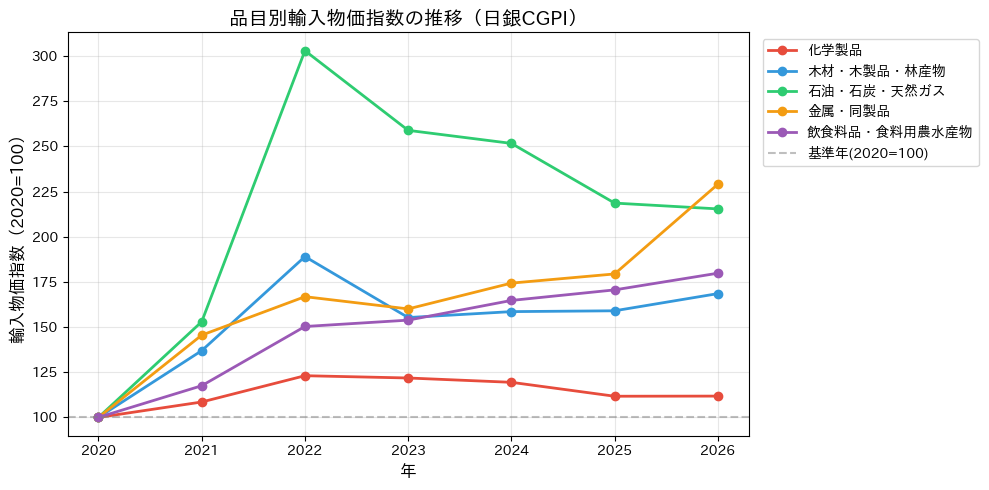

group_ja   化学製品  木材・木製品・林産物  石油・石炭・天然ガス  金属・同製品  飲食料品・食料用農水産物
year                                                         
2020      100.0       100.0       100.0   100.0         100.0
2021      108.5       136.9       152.9   145.5         117.5
2022      123.1       189.0       303.0   166.8         150.3
2023      121.8       155.2       258.9   160.0         153.8
2024      119.4       158.5       251.7   174.3         164.7
2025      111.7       159.0       218.6   179.4         170.6
2026      111.8       168.5       215.4   229.0         179.8


In [2]:
price_df = compute_annual_price_index()
pivot = price_df.pivot(index='year', columns='group_ja', values='price_index')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for (col, color) in zip(pivot.columns, colors):
    ax.plot(pivot.index, pivot[col], marker='o', label=col, color=color, linewidth=2)

ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='基準年(2020=100)')
ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('輸入物価指数（2020=100）', fontsize=12)
ax.set_title('品目別輸入物価指数の推移（日銀CGPI）', fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/price-indices/fig_import_price_index.png', dpi=150, bbox_inches='tight')
plt.show()
print(pivot.round(1))

## 1-2. グループ別交易損失の推移

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/trade-loss/trade_loss_by_group.csv
Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/trade-loss/trade_loss_total.csv


/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95192/883225803.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95192/883225803.py:38: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95192/883225803.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) IPAexGothic.
  plt.savefig('../data/processed/price-indices/fig_trade_loss_dual.png', dpi=150, bbox_inches='tight')
/var/folders/dq/w27rxm_96b522vs0dsrq53fw0000gn/T/ipykernel_95192/883225803.py:39: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) IPAexGothic.
  plt.savefig('../data/processed/price-indices/fig_trade_loss_dual.png', dpi=150, bbox_inches='tight')
/Users/ishidatomonori/Desktop/graduation-thesis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:

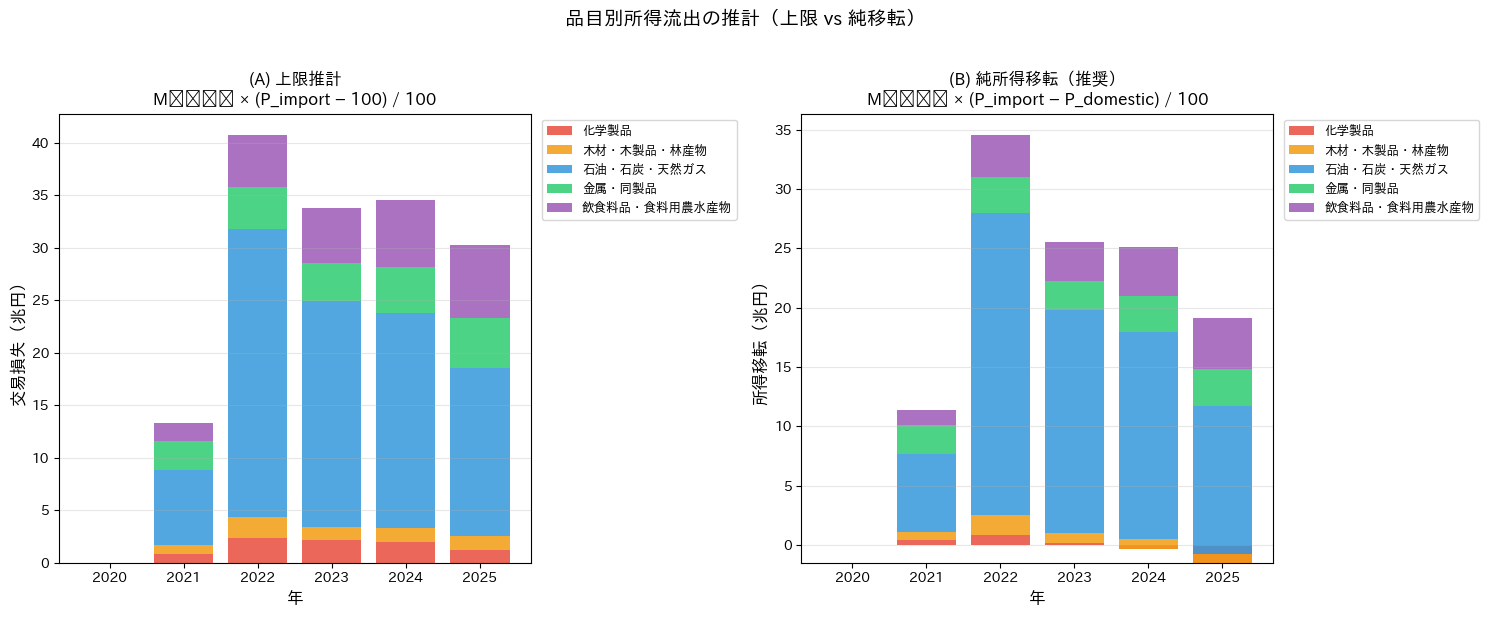


=== 推計比較 (兆円) ===
     年        上限推計       純所得移転
  2020: UB=  -0.0兆円   Net=  -0.0兆円
  2021: UB=  13.3兆円   Net=  11.4兆円
  2022: UB=  40.7兆円   Net=  34.6兆円
  2023: UB=  33.8兆円   Net=  25.6兆円
  2024: UB=  34.6兆円   Net=  25.1兆円
  2025: UB=  30.2兆円   Net=  19.1兆円

注: 純所得移転 = 輸入価格上昇分から国内物価上昇を差し引いた実質的な所得流出。
   内閣府SNA「交易利得（損失）」に近い概念。ただし輸出価格効果は含まない。


In [3]:
loss_df = compute_trade_loss()
total_df = compute_total_trade_loss()

# Focus on 2020-2025
plot_df = loss_df[loss_df['year'].between(2020, 2025)]
total_plot = total_df[total_df['year'].between(2020, 2025)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Upper bound (stacked by group)
ax = axes[0]
pivot_ub = plot_df.pivot(index='year', columns='group_ja', values='trade_loss_ub_tn_jpy').fillna(0)
bottom = pd.Series(0, index=pivot_ub.index)
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
for col, color in zip(pivot_ub.columns, colors):
    ax.bar(pivot_ub.index, pivot_ub[col], bottom=bottom, label=col, color=color, alpha=0.85)
    bottom += pivot_ub[col]
ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('交易損失（兆円）', fontsize=12)
ax.set_title('(A) 上限推計\nM₂₀₂₀ × (P_import − 100) / 100', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: Net income transfer (stacked by group)
ax = axes[1]
pivot_net = plot_df.pivot(index='year', columns='group_ja', values='trade_loss_net_tn_jpy').fillna(0)
bottom = pd.Series(0, index=pivot_net.index)
for col, color in zip(pivot_net.columns, colors):
    ax.bar(pivot_net.index, pivot_net[col], bottom=bottom, label=col, color=color, alpha=0.85)
    bottom += pivot_net[col]
ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('所得移転（兆円）', fontsize=12)
ax.set_title('(B) 純所得移転（推奨）\nM₂₀₂₀ × (P_import − P_domestic) / 100', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('品目別所得流出の推計（上限 vs 純移転）', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/price-indices/fig_trade_loss_dual.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== 推計比較 (兆円) ===')
print(f"{'年':>6}  {'上限推計':>10}  {'純所得移転':>10}")
for _, row in total_plot.iterrows():
    print(f"  {int(row['year'])}: UB={row['total_ub_tn_jpy']:6.1f}兆円   Net={row['total_net_tn_jpy']:6.1f}兆円")

print('\n注: 純所得移転 = 輸入価格上昇分から国内物価上昇を差し引いた実質的な所得流出。')
print('   内閣府SNA「交易利得（損失）」に近い概念。ただし輸出価格効果は含まない。')

## 1-3. IO表から見た輸入含有率（5グループ）

Loading cached: /Users/ishidatomonori/Desktop/graduation-thesis/data/processed/import-content/group_import_content.csv


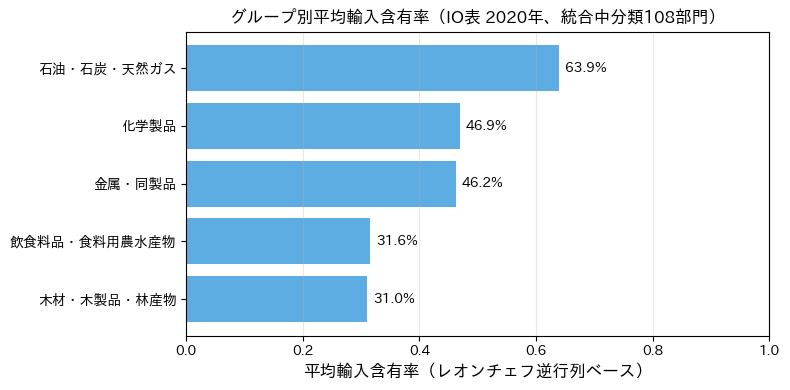

    group_ja  n_sectors  import_value_total  avg_import_content
  石油・石炭・天然ガス          5             13551.7            0.638971
        化学製品         10             10006.7            0.469074
飲食料品・食料用農水産物          7              9853.6            0.315807
      金属・同製品          8              5911.5            0.462187
  木材・木製品・林産物          5              2273.9            0.310375


In [4]:
group_ic = compute_group_import_content()
group_ic_plot = group_ic.sort_values('avg_import_content', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    group_ic_plot['group_ja'],
    group_ic_plot['avg_import_content'],
    color='#3498db', alpha=0.8
)
ax.set_xlabel('平均輸入含有率（レオンチェフ逆行列ベース）', fontsize=12)
ax.set_title('グループ別平均輸入含有率（IO表 2020年、統合中分類108部門）', fontsize=12)
for bar, val in zip(bars, group_ic_plot['avg_import_content']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/import-content/fig_group_import_content.png', dpi=150, bbox_inches='tight')
plt.show()
print(group_ic[['group_ja', 'n_sectors', 'import_value_total', 'avg_import_content']].to_string(index=False))